# Comparative Analysis of Multi-Objective Optimizers for Location Optimization

This notebook performs a systematic comparison of four multi-objective optimization algorithms
applied to the map-based location optimization problem from Sun et al. (DOCS 2023):

- **PSO-DN**: Particle Swarm Optimization with Dynamic Neighborhood (the proposed algorithm)
- **MOPSO-CD**: Multi-Objective PSO with Crowding Distance
- **NSGA-II**: Non-dominated Sorting Genetic Algorithm II (pymoo)
- **NSGA-III**: Non-dominated Sorting Genetic Algorithm III (pymoo)

The analysis covers: hyperparameter tuning for PSO-DN, algorithm comparison on the original map,
benchmark on the DTLZ3 problem with multiple local Pareto fronts, and validation on the ZDT1 benchmark.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# pymoo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.core.problem import Problem
from pymoo.core.callback import Callback

# Project modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.problem import LocationProblem
from src.archives import Archive
from src.optimizers.pso_dn import PSODN
from src.optimizers.mopso_cd import MOPSO_CD
from src.plot_utils import plot_city_map_with_solutions
from data.test_map import facilities, infrastructure, map_styles, x_bounds, v_bounds, REGIONS
from src.mo_utils import igdx_kdtree, coverage_at_epsilon, in_box, count_solutions_by_region


In [4]:
# ==========================================
# Problem & Algorithm Constants
# ==========================================
D = 2
M = 4
K = [6, 3, 13, 3]

POP_SIZE = 110 * D        # = 220
N_ITER_TUNING = 40
N_ITER_COMPARISON = 50

W = 0.729
C1 = 1.49445
C2 = 1.49445

R_L_CANDIDATES = [2.0, 5.0, 10.0, 15.0, 20.0, 30.0]
BEST_R_L = 10.0           # will be confirmed by tuning

N_RUNS_TUNING = 30
N_RUNS_MAIN = 30
N_RUNS_QUICK = 15

np.random.seed(42)
MASTER_SEEDS = np.random.randint(0, 100000, size=max(N_RUNS_TUNING, N_RUNS_MAIN, N_RUNS_QUICK))

# Initialize the location problem
problem = LocationProblem(
    D=D, M=M, K=K,
    facilities=facilities,
    infrastructure=infrastructure,
    map_styles=map_styles,
    x_bounds=x_bounds
)

# Pymoo wrapper for the location problem
class PymooLocationWrapper(Problem):
    def __init__(self, loc_prob):
        self.loc_prob = loc_prob
        super().__init__(
            n_var=loc_prob.D,
            n_obj=loc_prob.M,
            n_ieq_constr=0,
            xl=np.array(loc_prob.x_bounds)[:, 0],
            xu=np.array(loc_prob.x_bounds)[:, 1]
        )

    def _evaluate(self, x, out, *args, **kwargs):
        out["F"] = self.loc_prob.evaluate_population(x)

pymoo_problem = PymooLocationWrapper(problem)

# Reference points for Hypervolume
REF_200 = np.array([200, 200, 200, 200])
REF_400 = np.array([400, 400, 400, 400])
hv_200 = HV(ref_point=REF_200)
hv_400 = HV(ref_point=REF_400)

# Cache directory for results
CACHE_DIR = os.path.join(project_root, 'results')
os.makedirs(CACHE_DIR, exist_ok=True)

FORCE_RECOMPUTE = False  # set True to re-run all (overwrites cached results)

---
## 1. Hyperparameter Tuning: R_l for PSO-DN

The dynamic radius parameter $R_l$ controls the initial neighborhood size used in the sub-population assignment
(Algorithm 2 in the paper). It determines how coarsely the swarm is partitioned: small $R_l$ creates many
small sub-populations (more exploration), while large $R_l$ creates few large sub-populations (more exploitation).

We tune $R_l$ over 30 independent runs with fixed seeds, selecting the value with the highest mean Hypervolume.

In [5]:
# ==========================================
# Hyperparameter Tuning Loop
# ==========================================
TUNING_CACHE = os.path.join(CACHE_DIR, 'tuning_results.json')

if FORCE_RECOMPUTE or not os.path.exists(TUNING_CACHE):
    tuning_results_200 = {rl: [] for rl in R_L_CANDIDATES}
    tuning_results_400 = {rl: [] for rl in R_L_CANDIDATES}
    tuning_solutions_X = {rl: [] for rl in R_L_CANDIDATES}
    tuning_solutions_F = {rl: [] for rl in R_L_CANDIDATES}

    print("Starting Hyperparameter Tuning for R_l...\n")
    for i, seed in enumerate(tqdm(MASTER_SEEDS[:N_RUNS_TUNING], desc="Tuning runs")):
        for rl in R_L_CANDIDATES:
            np.random.seed(seed)

            optimizer = PSODN(pop_size=POP_SIZE, n_iter=N_ITER_TUNING, R_l=rl,
                              w=W, c1=C1, c2=C2, v_bounds=v_bounds)
            archive, _ = optimizer.optimize(problem, verbose=False)
            X, F = archive.extract_arrays()
            X_clean, F_clean = problem.impose_infrastructure_constraints(X, F)

            tuning_solutions_X[rl].append(X_clean)
            tuning_solutions_F[rl].append(F_clean)

            score_200 = hv_200(F_clean) if len(F_clean) > 0 else 0.0
            score_400 = hv_400(F_clean) if len(F_clean) > 0 else 0.0
            tuning_results_200[rl].append(score_200)
            tuning_results_400[rl].append(score_400)

    # Save to cache
    cache = {
        'R_L_CANDIDATES': R_L_CANDIDATES,
        'results_200': {str(rl): tuning_results_200[rl] for rl in R_L_CANDIDATES},
        'results_400': {str(rl): tuning_results_400[rl] for rl in R_L_CANDIDATES},
        'solutions_X': {str(rl): [arr.tolist() for arr in tuning_solutions_X[rl]] for rl in R_L_CANDIDATES},
        'solutions_F': {str(rl): [arr.tolist() for arr in tuning_solutions_F[rl]] for rl in R_L_CANDIDATES},
    }
    with open(TUNING_CACHE, 'w') as f:
        json.dump(cache, f, indent=2)
    print(f"Results cached to {TUNING_CACHE}")
else:
    with open(TUNING_CACHE, 'r') as f:
        cache = json.load(f)
    tuning_results_200 = {float(rl): cache['results_200'][str(rl)] for rl in cache['R_L_CANDIDATES']}
    tuning_results_400 = {float(rl): cache['results_400'][str(rl)] for rl in cache['R_L_CANDIDATES']}
    tuning_solutions_X = {float(rl): [np.array(arr) for arr in cache['solutions_X'][str(rl)]] for rl in cache['R_L_CANDIDATES']}
    tuning_solutions_F = {float(rl): [np.array(arr) for arr in cache['solutions_F'][str(rl)]] for rl in cache['R_L_CANDIDATES']}
    print(f"Loaded tuning results from cache ({TUNING_CACHE})")

Loaded tuning results from cache (c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\tuning_results.json)


================ TUNING SUMMARY ================
R_l     | Mean HV200     | Std HV200   | Mean HV400      | Std HV400   | Avg Sols  
--------------------------------------------------------------------------------
2.0     | 1554740192.5452 | 4334277.2333 | 25338721732.6189 | 35019146.6457 | 525.8     
5.0     | 1555493070.8223 | 5097887.6256 | 25345770550.9843 | 36287453.4651 | 539.3     
10.0    | 1555549369.0275 | 5198807.3480 | 25346152293.6097 | 36995403.5930 | 573.6     
15.0    | 1553866108.0965 | 4980087.2614 | 25333675810.0924 | 34366631.6007 | 592.4     
20.0    | 1555405782.8428 | 5525896.5482 | 25345729319.9907 | 38310487.9099 | 689.3     
30.0    | 1554949034.1979 | 5523734.9054 | 25341943967.9284 | 40198360.5550 | 516.9     

Best R_l by mean HV200: 10.0


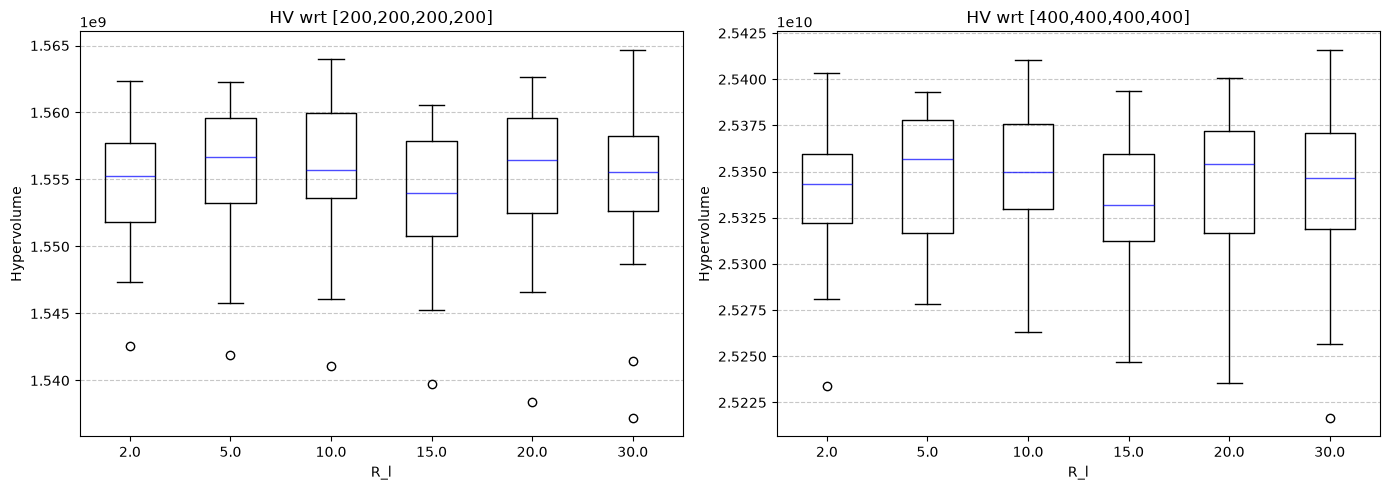

In [6]:
# ==========================================
# Tuning Summary & Visualization
# ==========================================
print("================ TUNING SUMMARY ================")
print(f"{'R_l':<7} | {'Mean HV200':<14} | {'Std HV200':<11} | {'Mean HV400':<15} | {'Std HV400':<11} | {'Avg Sols':<10}")
print("-" * 80)

best_mean_hv = -np.inf
best_rl = R_L_CANDIDATES[0]
for rl in R_L_CANDIDATES:
    m200 = np.mean(tuning_results_200[rl])
    s200 = np.std(tuning_results_200[rl])
    m400 = np.mean(tuning_results_400[rl])
    s400 = np.std(tuning_results_400[rl])
    avg_sols = np.mean([len(F) for F in tuning_solutions_F[rl]])
    print(f"{rl:<7} | {m200:<14.4f} | {s200:<11.4f} | {m400:<15.4f} | {s400:<11.4f} | {avg_sols:<10.1f}")
    if m200 > best_mean_hv:
        best_mean_hv = m200
        best_rl = rl

print(f"\nBest R_l by mean HV200: {best_rl}")
BEST_R_L = best_rl

# Boxplot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.boxplot([tuning_results_200[rl] for rl in R_L_CANDIDATES], tick_labels=R_L_CANDIDATES, medianprops=dict(color="blue", alpha=0.7))
ax1.set_title("HV wrt [200,200,200,200]")
ax1.set_xlabel("R_l")
ax1.set_ylabel("Hypervolume")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.boxplot([tuning_results_400[rl] for rl in R_L_CANDIDATES], tick_labels=R_L_CANDIDATES, medianprops=dict(color="blue", alpha=0.7))
ax2.set_title("HV wrt [400,400,400,400]")
ax2.set_xlabel("R_l")
ax2.set_ylabel("Hypervolume")
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 3. Algorithm Comparison on the Original Map

## 3.1. Comparison methodology

A key challenge in comparing PSO-based algorithms (PSO-DN, MOPSO-CD) with genetic algorithms (NSGA-II/III)
is that the PSO variants maintain a **global archive** (GBA) that accumulates non-dominated solutions across
all iterations, while NSGA-II/III only return the non-dominated front from the **final population**.

To ensure a fair comparison, we attach a pymoo `Callback` to the NSGA algorithms that extracts the
population at each generation and feeds it into the same `Archive.update_with_dominance()` method
used by the custom PSO algorithms. This gives NSGA-II/III the same archival capability.

In [7]:
class ArchiveCallback(Callback):
    """
    Pymoo callback that collects non-dominated solutions from each generation
    into an Archive, simulating the same archival behavior as the custom PSO optimizers.
    """
    def __init__(self, global_archive):
        super().__init__()
        self.global_archive = global_archive

    def notify(self, algorithm):
        pop_X = algorithm.pop.get("X")
        pop_F = algorithm.pop.get("F")
        self.global_archive.update_with_dominance(pop_X, pop_F)

## 3.2 Metrics
We compare the four algorithms over 30 independent runs with shared random seeds.

Let $A$ be the approximation set returned by an algorithm, $R_F$ the reference Pareto front in objective space, and $R_X$ the reference Pareto set in decision space.

- **Hypervolume (HV)**  
  Measures the volume dominated by the approximation set $A$ with respect to a reference point $r$ in objective space:
  $$
  HV(A,r) = \lambda \left( \bigcup_{f(x) \in A} [f_1(x), r_1] \times \cdots \times [f_m(x), r_m] \right).
  $$
  Higher values are better. We compute it using the fixed reference points $(200,\dots,200)$, $(400,\dots,400)$, and a "dynamic" reference point $1.1 \cdot \max(F)$, where $\max(F)$ is computed over all algorithms and all 30 runs combined.

- **IGDX**  
  Measures how well the algorithm approximates the Pareto set in decision space:
  $$
  \operatorname{IGDX}(A_X, R_X) =
  \frac{1}{|R_X|}
  \sum_{x \in R_X}
  \min_{a \in A_X} \|x-a\|.
  $$
  Lower values are better.

- **Number of solutions**  
  Counts the number of feasible non-dominated solutions returned by each algorithm after removing points on roads and railways. A larger value does not necessarily imply better coverage.

- **Region-wise solution counts**  
  Counts how many solutions fall inside each known Pareto set $R_1, R_2, R_3$. This helps distinguish whether an algorithm concentrates solutions in one region or spreads them across multiple Pareto sets.

- **Number of regions discovered**  
  Counts how many Pareto sets contain at least a minimum number of solutions:
  $$
  N_{\text{regions}} =
  \sum_{i=1}^{3}
  \mathbf{1}\{|A_X \cap R_i| \geq \tau\}.
  $$
  Higher values indicate better multimodal discovery.

- **All-regions-found percentage**  
  Percentage of independent runs in which all three Pareto sets are discovered:
  $$
  \frac{\#\{\text{runs where all regions are found}\}}{\#\{\text{runs}\}}
  \times 100.
  $$
  Higher values indicate more reliable recovery of the multimodal structure.

- **Region-wise IGDX**  
  Computes IGDX separately on each Pareto-set region:
  $$
  \operatorname{IGDX}_i =
  \frac{1}{|R_X^i|}
  \sum_{x \in R_X^i}
  \min_{a \in A_X} \|x-a\|.
  $$
  Lower values mean better approximation of that specific region.

- **Balanced IGDX**  
  Averages the region-wise IGDX values, giving the same weight to each Pareto-set region:
  $$
  \operatorname{IGDX}_{\text{bal}} =
  \frac{1}{3}
  \sum_{i=1}^{3} \operatorname{IGDX}_i.
  $$
  This avoids the global IGDX being dominated by the largest reference region.

- **Coverage@$\varepsilon$**  
  Measures the fraction of reference points that are within distance $\varepsilon$ from at least one solution:
  $$
  C_\varepsilon =
  \frac{1}{|R_X|}
  \sum_{x \in R_X}
  \mathbf{1}
  \left\{
  \min_{a \in A_X} \|x-a\| \leq \varepsilon
  \right\}.
  $$
  Higher values indicate better coverage. 

- **Balanced coverage@$\varepsilon$**  
  Computes coverage separately on each Pareto-set region and then averages across regions:
  $$
  C_{\varepsilon,\text{bal}} =
  \frac{1}{3}
  \sum_{i=1}^{3} C_{\varepsilon}^{i}.
  $$
  Higher values indicate better balanced coverage across the different Pareto sets.

- **Mean and standard deviation over runs**  
  Each metric is computed over multiple independent runs. The mean summarizes average performance, while the standard deviation measures stability:
  $$
  \mu = \frac{1}{n}\sum_{j=1}^{n} m_j,
  \qquad
  \sigma =
  \sqrt{
  \frac{1}{n}
  \sum_{j=1}^{n}(m_j-\mu)^2
  }.
  $$

Coverage is computed using $\varepsilon = 0.05$, which is equal to the step used for the grid of the reference Pareto set.

In [8]:
# Parameters for the comparison

algorithms_dict = {
    "PSO-DN": lambda: PSODN(pop_size=POP_SIZE, n_iter=N_ITER_COMPARISON, R_l=BEST_R_L,
                             w=W, c1=C1, c2=C2, v_bounds=v_bounds),
    "MOPSO-CD": lambda: MOPSO_CD(pop_size=POP_SIZE, n_iter=N_ITER_COMPARISON, Q=10000,
                                  tourn_size=2, w=W, c1=C1, c2=C2, v_bounds=v_bounds),
    "NSGA-II": lambda: NSGA2(pop_size=POP_SIZE),
    "NSGA-III": lambda: NSGA3(pop_size=POP_SIZE, ref_dirs=get_reference_directions("das-dennis", M, n_partitions=9))
}
algo_names = list(algorithms_dict.keys())
n_algo = len(algo_names)

In [9]:
# Main comparison loop

MAIN_CACHE = os.path.join(CACHE_DIR, 'comparison_main.json')

if FORCE_RECOMPUTE or not os.path.exists(MAIN_CACHE):
    algo_hv200 = {a: [] for a in algo_names}
    algo_hv400 = {a: [] for a in algo_names}
    algo_hvdyn = {a: [] for a in algo_names}
    algo_nsols = {a: [] for a in algo_names}
    algo_X = {a: [] for a in algo_names}
    algo_F = {a: [] for a in algo_names}

    print("Starting Algorithm Comparison on Original Map...\n")
    for run_idx, seed in enumerate(tqdm(MASTER_SEEDS[:N_RUNS_MAIN], desc="Comparison (orig map)")):

        for algo_name in algo_names:
            np.random.seed(seed)

            if algo_name in ["PSO-DN", "MOPSO-CD"]:
                optimizer = algorithms_dict[algo_name]()
                archive, _ = optimizer.optimize(problem, verbose=False)
                X, F = archive.extract_arrays()
            else:
                optimizer = algorithms_dict[algo_name]()
                gba = Archive()
                callback = ArchiveCallback(gba)
                res = minimize(pymoo_problem, optimizer, ('n_gen', N_ITER_COMPARISON),
                               seed=seed, callback=callback, verbose=False)
                gba.remove_similar_solutions(decimals=4)
                X, F = gba.extract_arrays()

            X_clean, F_clean = problem.impose_infrastructure_constraints(X, F)
            algo_X[algo_name].append(X_clean)
            algo_F[algo_name].append(F_clean)
            algo_nsols[algo_name].append(len(F_clean))

            h200 = hv_200(F_clean) if len(F_clean) > 0 else 0.0
            h400 = hv_400(F_clean) if len(F_clean) > 0 else 0.0
            algo_hv200[algo_name].append(h200)
            algo_hv400[algo_name].append(h400)

    # Single global dynamic HV reference point (over all runs x all algorithms)
    all_F_global = np.vstack([F_arr for a in algo_names for F_arr in algo_F[a] if len(F_arr) > 0])
    if len(all_F_global) > 0:
        global_dyn_ref = np.max(all_F_global, axis=0) * 1.1
        hv_global_dyn = HV(ref_point=global_dyn_ref)
        for a in algo_names:
            algo_hvdyn[a] = [float(hv_global_dyn(F_arr)) if len(F_arr) > 0 else 0.0 for F_arr in algo_F[a]]
    else:
        for a in algo_names:
            algo_hvdyn[a] = [0.0] * len(algo_F[a])

    # Save cache
    cache = {
        '_meta': {'global_dyn_ref': global_dyn_ref.tolist() if len(all_F_global) > 0 else None},
        'hv200': {a: algo_hv200[a] for a in algo_names},
        'hv400': {a: algo_hv400[a] for a in algo_names},
        'hvdyn': {a: algo_hvdyn[a] for a in algo_names},
        'nsols': {a: algo_nsols[a] for a in algo_names},
        'X_all': {a: [arr.tolist() for arr in algo_X[a]] for a in algo_names},
        'F_all': {a: [arr.tolist() for arr in algo_F[a]] for a in algo_names},
    }
    with open(MAIN_CACHE, 'w') as f:
        json.dump(cache, f, indent=2)
    print(f"Results cached to {MAIN_CACHE}")
else:
    with open(MAIN_CACHE, 'r') as f:
        cache = json.load(f)
    algo_hv200 = cache['hv200']
    algo_hv400 = cache['hv400']
    algo_hvdyn = cache['hvdyn']
    algo_nsols = cache['nsols']
    algo_X = {a: [np.array(arr) for arr in cache['X_all'][a]] for a in algo_names}
    algo_F = {a: [np.array(arr) for arr in cache['F_all'][a]] for a in algo_names}
    print(f"Loaded tuning results from cache ({MAIN_CACHE})")


Loaded tuning results from cache (c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\comparison_main.json)


Raw reference points: 158,592
Clean IGDX reference points: 115,490


c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\src\plot_utils.py:79: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_coords, y_coords, color=color, marker=marker, s=size,


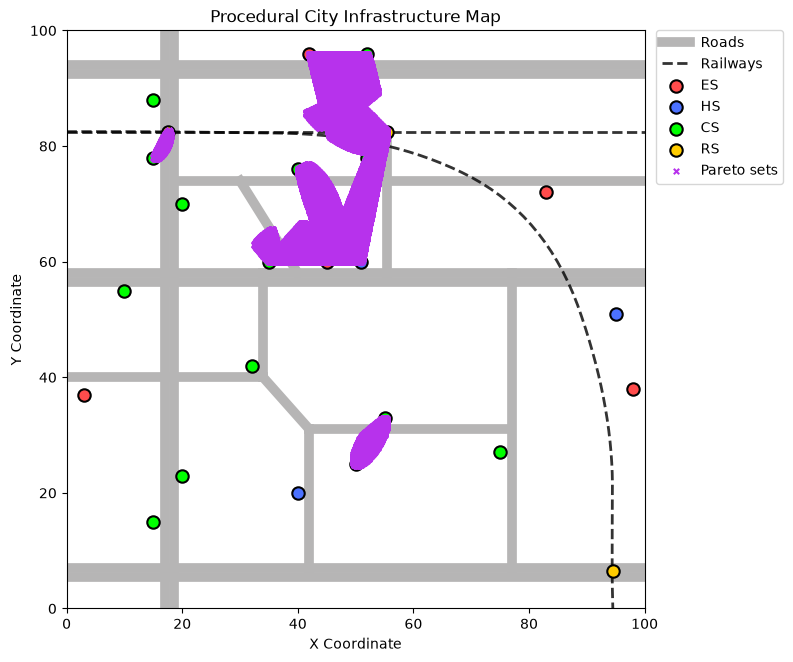

In [10]:
# ==========================================
# Compute IGDX on Location Problem
# ==========================================

TRUE_PARETO_PATH = os.path.join(project_root, "data", "true_pareto_step0.05.npz")

d_true = np.load(TRUE_PARETO_PATH)
X_ref_raw = d_true["X_true"]
F_ref_raw = d_true["F_true"]

# Clean the reference set from infrastructure contraints.
X_ref_clean, F_ref_clean = problem.impose_infrastructure_constraints(X_ref_raw, F_ref_raw)

# Remove duplicated decision points after rounding (in case step size is changed)
X_ref_igdx = np.unique(np.round(X_ref_clean, decimals=4), axis=0)

print(f"Raw reference points: {len(X_ref_raw):,}")
print(f"Clean IGDX reference points: {len(X_ref_igdx):,}")

algo_igdx = {a: [] for a in algo_names}

for algo_name in algo_names:
    for X_arr in algo_X[algo_name]:

        if len(X_arr) == 0:
            # No feasible solutions found: worst/failed case.
            algo_igdx[algo_name].append(999.0)
            continue

        algo_igdx[algo_name].append(igdx_kdtree(X_ref_igdx, X_arr))

plot_city_map_with_solutions(facilities, infrastructure, map_styles,
        X_ref_raw, label="Pareto sets",
        color="#B732EC", marker="x", size=15)

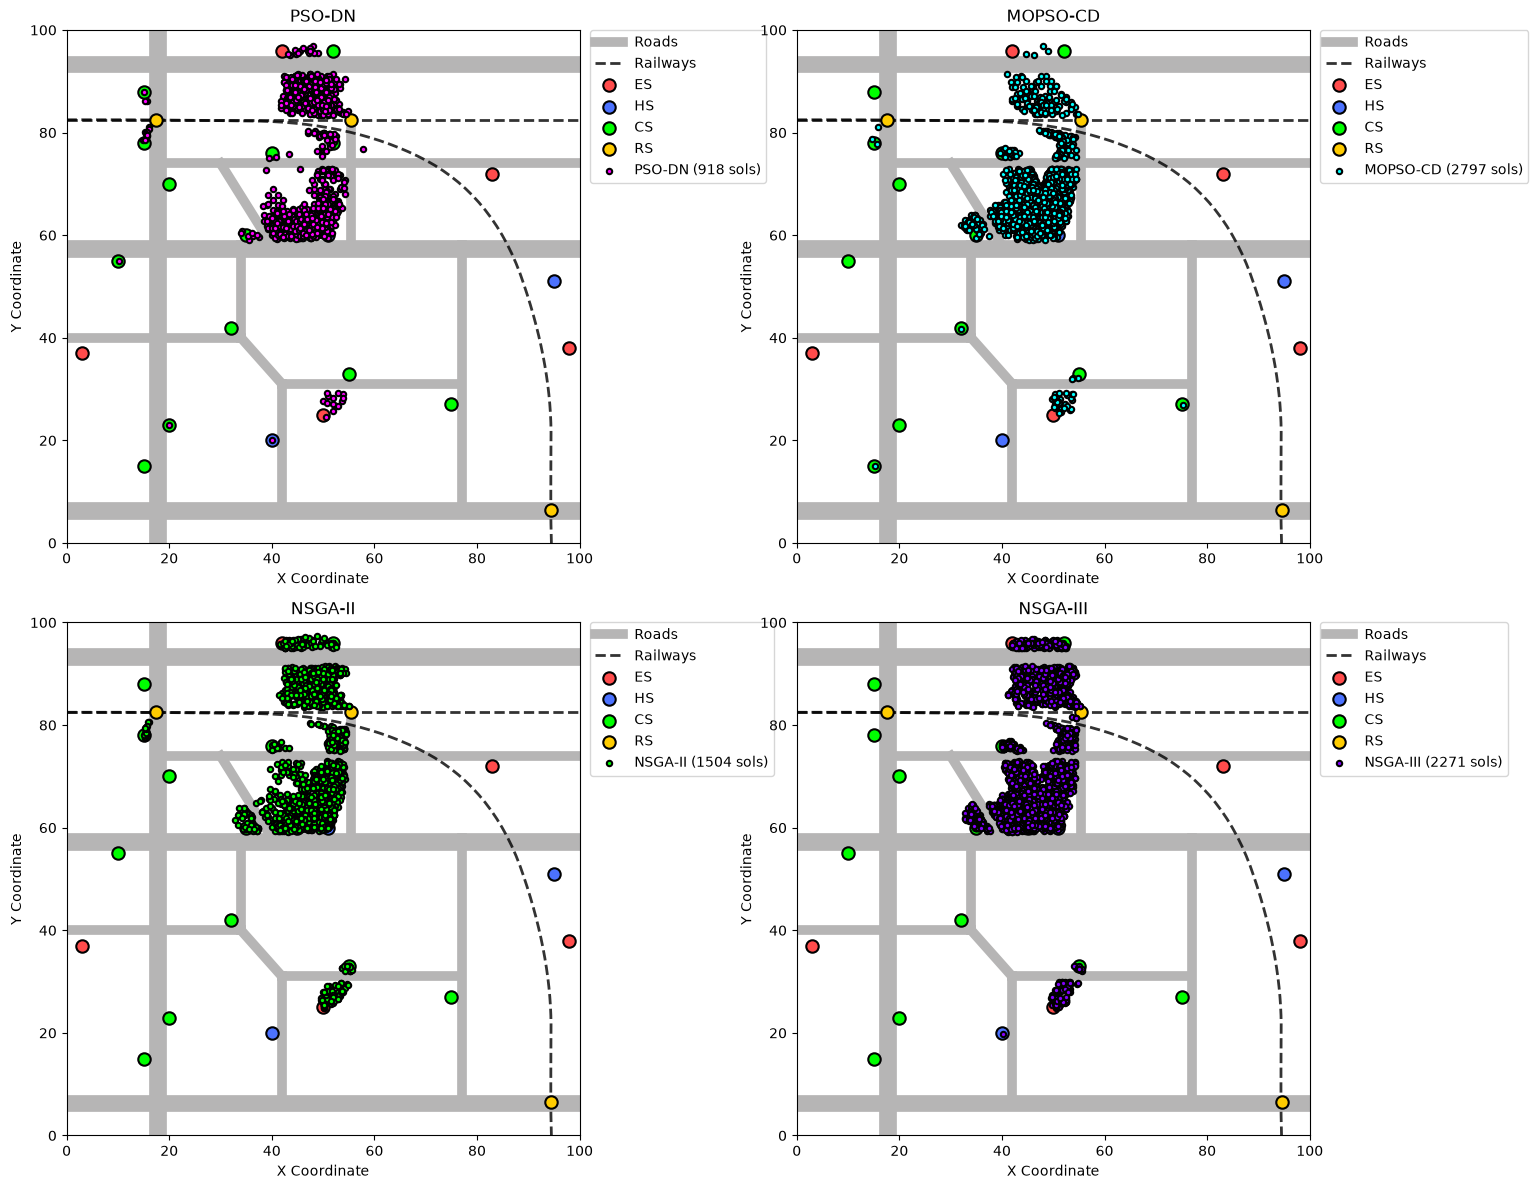

In [11]:
# solutions map visualization
if any(len(v) > 0 for v in algo_X.values()):
    last_run_X = [algo_X[a][1] for a in algo_names]
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    colors = ["#ff00ff", "#00ffff", "#00ff00", "#8400ff"]
    for ax, X, name, color in zip(axes.flatten(), last_run_X, algo_names, colors):
        if len(X) > 0:
            plot_city_map_with_solutions(
                facilities, infrastructure, map_styles,
                X, label=f"{name} ({len(X)} sols)",
                color=color, marker="o", size=15, ax=ax
            )
        ax.set_title(name)
    plt.tight_layout()
    plt.show()
else:
    print("Solution arrays not available.")

---
## 4. Results
### 4.1 Global comparison metrics

The first table summarizes the global performance of the algorithms on the original map.  
For the Hypervolume indicators, **larger values are better**. For IGDX, **smaller values are better**, because it measures the average distance from the reference Pareto set in decision space to the closest solution found by the algorithm.

In [12]:
summary_rows = []

for algo_name in algo_names:
    summary_rows.append({
        "Algorithm": algo_name,

        # Objective-space quality: larger is better
        "Mean HV200": np.mean(algo_hv200[algo_name]),
        "Std HV200": np.std(algo_hv200[algo_name]),
        "Mean HV400": np.mean(algo_hv400[algo_name]),
        "Std HV400": np.std(algo_hv400[algo_name]),
        "Mean HVdyn": np.mean(algo_hvdyn[algo_name]),
        "Std HVdyn": np.std(algo_hvdyn[algo_name]),

        # Decision-space quality: smaller is better
        "Mean IGDX": np.mean(algo_igdx[algo_name]),
        "Std IGDX": np.std(algo_igdx[algo_name]),

        # Size of the final non-dominated archive
        "Mean Sols": np.mean(algo_nsols[algo_name]),
        "Std Sols": np.std(algo_nsols[algo_name]),
    })

summary_df = pd.DataFrame(summary_rows)

summary_df_display = summary_df.copy()
numeric_cols = summary_df_display.select_dtypes(include=[np.number]).columns
summary_df_display[numeric_cols] = summary_df_display[numeric_cols].round(2)

summary_df_display

,Algorithm,Mean HV200,Std HV200,Mean HV400,Std HV400,Mean HVdyn,Std HVdyn,Mean IGDX,Std IGDX,Mean Sols,Std Sols
0,PSO-DN,1.557029e+09,5250900.88,2.535712e+10,40716017.26,3769096.12,90203.57,0.76,0.34,724.27,213.44
1,MOPSO-CD,1.556564e+09,3957817.36,2.534579e+10,33953556.38,3831074.75,25565.38,0.55,0.30,2710.53,400.03
2,NSGA-II,1.564141e+09,1076921.20,2.540585e+10,9672954.84,3898621.45,4716.95,0.36,0.35,1525.23,64.23
3,NSGA-III,1.563463e+09,1394677.90,2.539927e+10,12917739.94,3897791.98,6247.08,0.25,0.03,2178.40,91.30


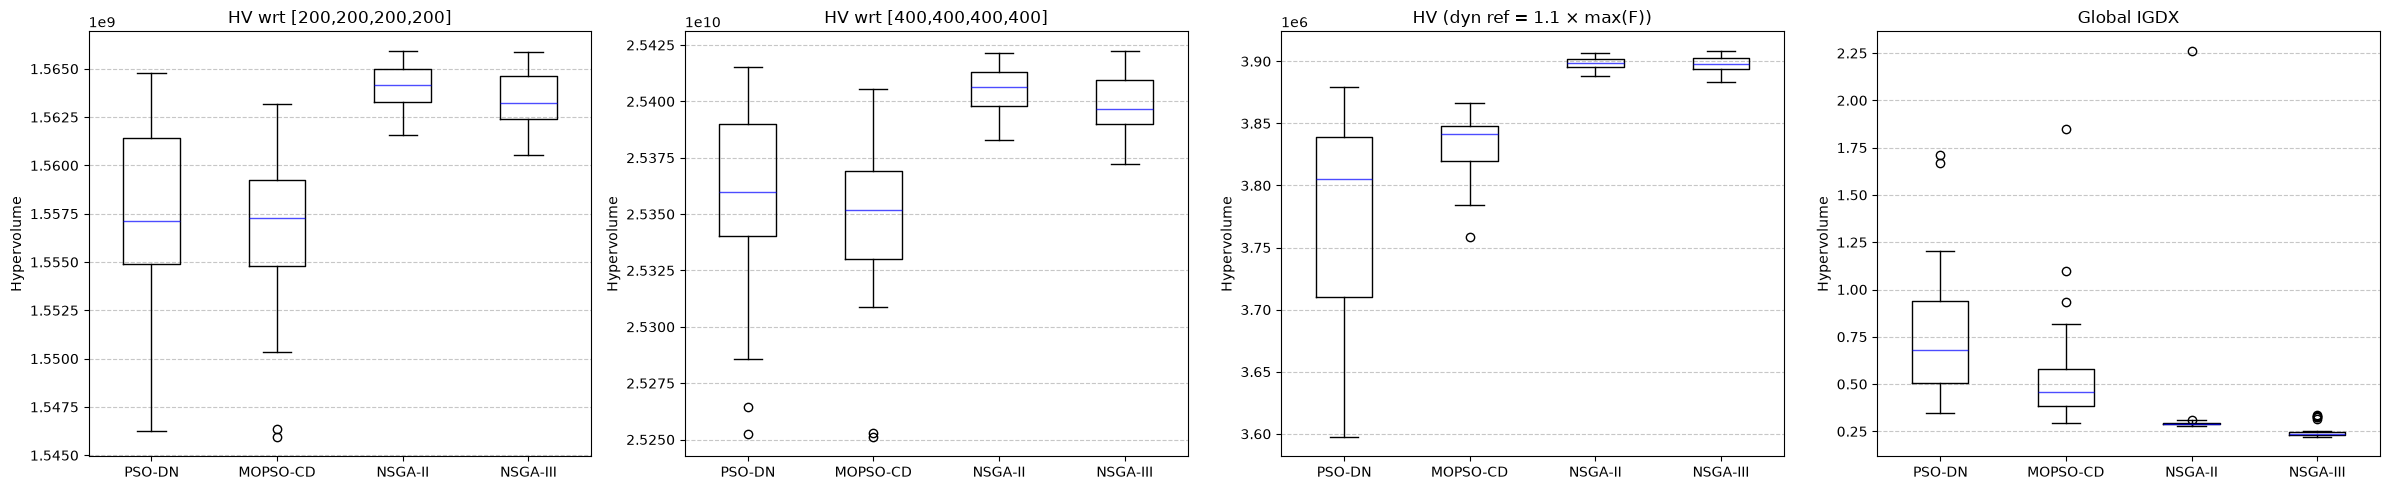

In [13]:
# Boxplot comparison
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

plot_data = [
    (algo_hv200, "HV wrt [200,200,200,200]", "Hypervolume"),
    (algo_hv400, "HV wrt [400,400,400,400]", "Hypervolume"),
    (algo_hvdyn, "HV (dyn ref = 1.1 × max(F))", "Hypervolume"),
    (algo_igdx, "Global IGDX", "IGDX"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_data):
    ax.boxplot([metric[a] for a in algo_names], tick_labels=algo_names, medianprops=dict(color="blue", alpha=0.7))
    ax.set_title(title)
    ax.set_ylabel("Hypervolume")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.2 Region-wise Pareto-set analysis

The global IGDX is useful, but it is influenced by the fact that the third Pareto region contains many more reference points than the first two.  
For this reason, we also compute region-wise indicators:

- **regions found**: how many of the three disconnected Pareto-set regions are discovered;
- **all regions found (%)**: percentage of runs in which all three regions are discovered;
- **region-wise IGDX**: IGDX computed separately on each Pareto region;
- **balanced IGDX**: average of the three region-wise IGDX values, giving the same weight to each Pareto region;
- **coverage@1.0**: fraction of reference points that are at distance at most 1 map unit from an obtained solution.

In [14]:
EPS_COVERAGE = 0.05         # distance threshold used for coverage
MIN_REGION_SOLUTIONS = 1    # number of solutions to say a region was discovered

# Split reference Pareto set into the three known regions
X_ref_regions = {}

for r_name, box in REGIONS.items():
    mask = in_box(X_ref_igdx, box)
    X_ref_regions[r_name] = X_ref_igdx[mask]
    print(f"{r_name}: {len(X_ref_regions[r_name]):,} reference points")

# Initialize metric containers
algo_region_counts = {a: [] for a in algo_names}
algo_regions_found = {a: [] for a in algo_names}
algo_all_regions_found = {a: [] for a in algo_names}

algo_region_igdx = {
    a: {r: [] for r in REGIONS.keys()}
    for a in algo_names
}

algo_region_coverage = {
    a: {r: [] for r in REGIONS.keys()}
    for a in algo_names
}

algo_balanced_igdx = {a: [] for a in algo_names}
algo_balanced_coverage = {a: [] for a in algo_names}

# Compute metrics for every run of every algorithm
for algo_name in algo_names:
    for X_arr in algo_X[algo_name]:

        X_eval = np.unique(np.round(X_arr, decimals=4), axis=0)

        # count solutions in each Pareto set
        counts = count_solutions_by_region(X_eval, regions=REGIONS)
        algo_region_counts[algo_name].append(counts)

        # check region discovery
        found = {
            r: counts[r] >= MIN_REGION_SOLUTIONS
            for r in REGIONS.keys()
        }

        n_found = sum(found.values())
        algo_regions_found[algo_name].append(n_found)
        algo_all_regions_found[algo_name].append(n_found == len(REGIONS))

        # compute region-wise IGDX and coverage
        igdx_values = []
        coverage_values = []

        for r_name, X_ref_r in X_ref_regions.items():

            igdx_r = igdx_kdtree(X_ref_r, X_eval)
            cov_r = coverage_at_epsilon(X_ref_r, X_eval, eps=EPS_COVERAGE)

            algo_region_igdx[algo_name][r_name].append(igdx_r)
            algo_region_coverage[algo_name][r_name].append(cov_r)

            igdx_values.append(igdx_r)
            coverage_values.append(cov_r)

        # balanced indicators: each Pareto region has the same weight
        algo_balanced_igdx[algo_name].append(float(np.mean(igdx_values)))
        algo_balanced_coverage[algo_name].append(float(np.mean(coverage_values)))

R1: 493 reference points
R2: 7,372 reference points
R3: 107,625 reference points


In [15]:
# Region-wise summary tables

rows = []

for algo_name in algo_names:
    row = {
        "Algorithm": algo_name,
        "Mean regions found": np.mean(algo_regions_found[algo_name]),
        "All regions found (%)": 100 * np.mean(algo_all_regions_found[algo_name]),
        "Balanced IGDX": np.mean(algo_balanced_igdx[algo_name]),
        "Std Balanced IGDX": np.std(algo_balanced_igdx[algo_name]),
        f"Balanced coverage@{EPS_COVERAGE}": np.mean(algo_balanced_coverage[algo_name]),
    }

    for r in REGIONS.keys():
        row[f"{r} count"] = np.mean([
            counts[r] for counts in algo_region_counts[algo_name]
        ])
        row[f"{r} IGDX"] = np.mean(algo_region_igdx[algo_name][r])
        row[f"{r} cov@{EPS_COVERAGE}"] = np.mean(algo_region_coverage[algo_name][r])

    rows.append(row)

region_metrics_df = pd.DataFrame(rows)

# Full table containing both global and region-wise measures
full_summary_df = summary_df.merge(
    region_metrics_df,
    on="Algorithm",
    how="left"
)

# Compact display table for the most important region-wise measures
region_overview_cols = [
    "Algorithm",
    "Mean regions found",
    "All regions found (%)",
    "Balanced IGDX",
    "Std Balanced IGDX",
    f"Balanced coverage@{EPS_COVERAGE}",
    "R1 IGDX", "R2 IGDX", "R3 IGDX",
    f"R1 cov@{EPS_COVERAGE}", f"R2 cov@{EPS_COVERAGE}", f"R3 cov@{EPS_COVERAGE}",
]

region_overview_df = region_metrics_df[region_overview_cols].copy()
numeric_cols = region_overview_df.select_dtypes(include=[np.number]).columns
region_overview_df[numeric_cols] = region_overview_df[numeric_cols].round(3)

region_overview_df

,Algorithm,Mean regions found,All regions found (%),Balanced IGDX,Std Balanced IGDX,Balanced coverage@0.05,R1 IGDX,R2 IGDX,R3 IGDX,R1 cov@0.05,R2 cov@0.05,R3 cov@0.05
0,PSO-DN,2.933,93.333,0.832,0.648,0.023,0.854,0.888,0.753,0.044,0.013,0.013
1,MOPSO-CD,2.867,86.667,1.450,2.239,0.027,3.348,0.458,0.544,0.003,0.015,0.063
2,NSGA-II,2.967,96.667,0.598,1.869,0.049,0.167,1.335,0.291,0.086,0.028,0.032
3,NSGA-III,2.833,83.333,1.523,2.808,0.040,4.078,0.257,0.233,0.036,0.040,0.045


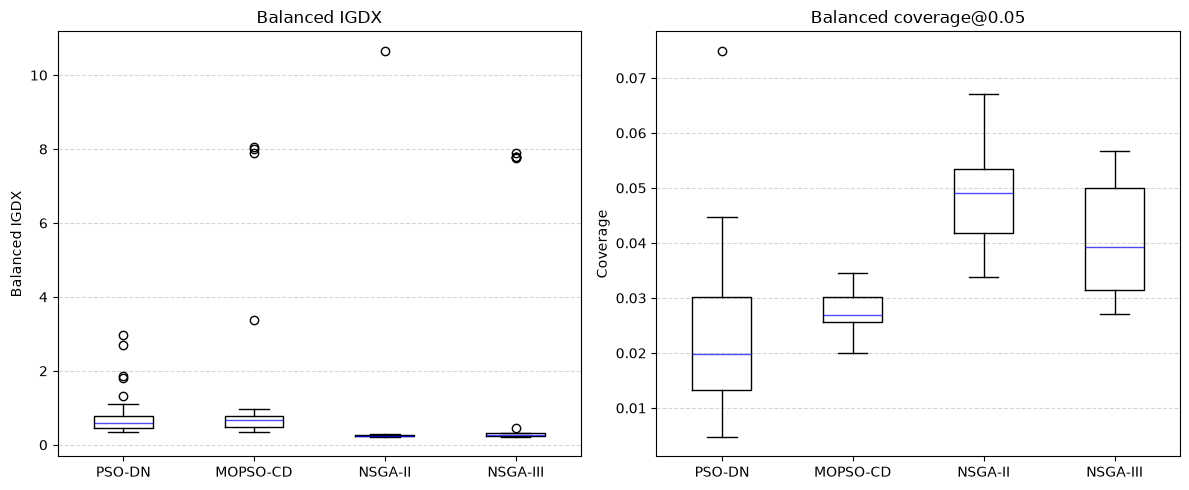

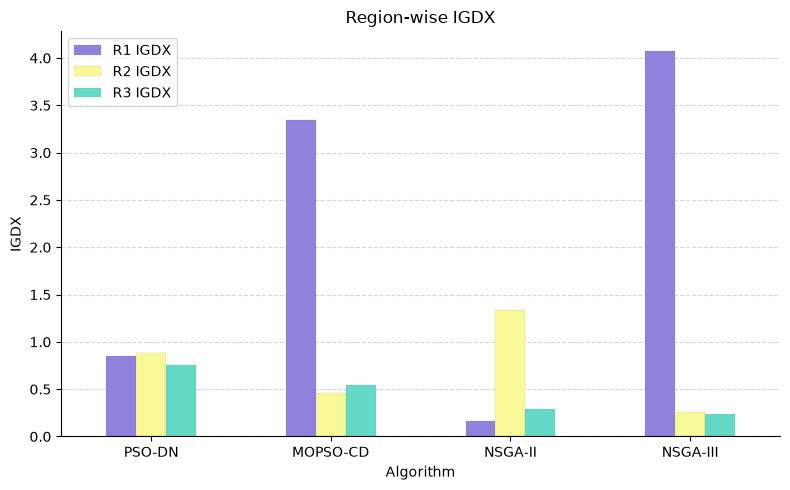

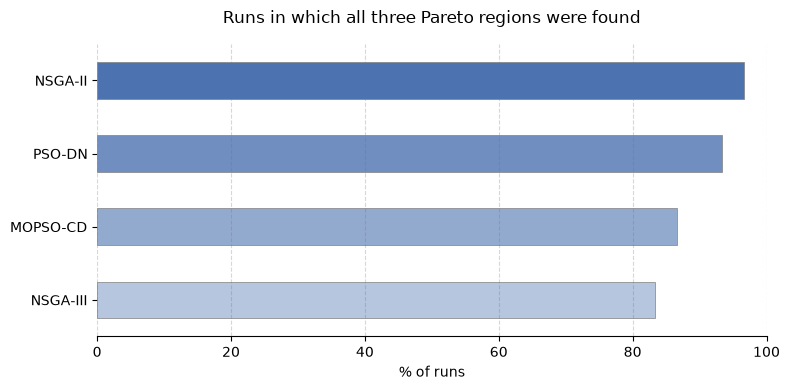

In [16]:
# boxplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

region_plot_data = [
    (algo_balanced_igdx, "Balanced IGDX", "Balanced IGDX"),
    # (algo_all_regions_found, "Number of regions found", "Regions found"),
    (algo_balanced_coverage, f"Balanced coverage@{EPS_COVERAGE}", "Coverage"),
]

for ax, (metric, title, ylabel) in zip(axes, region_plot_data):
    ax.boxplot([metric[a] for a in algo_names], tick_labels=algo_names, medianprops=dict(color="blue", alpha=0.7))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Region-wise IGDX bar plot
region_igdx_means = region_metrics_df.set_index("Algorithm")[
    [f"{r} IGDX" for r in REGIONS.keys()]
]
custom_colors = ["#8e82dc", "#f9f998", "#64dac6"]

ax = region_igdx_means.plot(kind="bar", figsize=(8, 5), color=custom_colors,edgecolor="grey", linewidth=0.1)
ax.set_axisbelow(True)
plt.title("Region-wise IGDX")
plt.ylabel("IGDX")
plt.xlabel("Algorithm")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Percentage of runs in which all regions were discovered
all_regions_pct = region_metrics_df.set_index("Algorithm")["All regions found (%)"].sort_values()
num_bars = len(all_regions_pct)
alphas = np.linspace(0.4, 1.0, num_bars)
base_color = plt.cm.colors.to_rgb("#4C72B0") 
rgba_colors = [(base_color[0], base_color[1], base_color[2], a) for a in alphas]

ax=all_regions_pct.plot(kind="barh", figsize=(8, 4),color=rgba_colors, edgecolor="grey", linewidth=0.5)
ax.set_axisbelow(True)
plt.title("Runs in which all three Pareto regions were found", pad=15)
plt.ylabel("")
plt.xlabel("% of runs")
plt.xticks(rotation=0)
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [17]:
# Full summary table, available for later inspection/export
full_summary_df_display = full_summary_df.copy()

numeric_cols = full_summary_df_display.select_dtypes(include=[np.number]).columns
full_summary_df_display[numeric_cols] = full_summary_df_display[numeric_cols].round(3)

full_summary_df_display

,Algorithm,Mean HV200,Std HV200,Mean HV400,Std HV400,Mean HVdyn,Std HVdyn,Mean IGDX,Std IGDX,Mean Sols,...,Balanced coverage@0.05,R1 count,R1 IGDX,R1 cov@0.05,R2 count,R2 IGDX,R2 cov@0.05,R3 count,R3 IGDX,R3 cov@0.05
0,PSO-DN,1.557029e+09,5250900.875,2.535712e+10,4.071602e+07,3769096.119,90203.573,0.762,0.344,724.267,...,0.023,16.933,0.854,0.044,57.933,0.888,0.013,602.800,0.753,0.013
1,MOPSO-CD,1.556564e+09,3957817.362,2.534579e+10,3.395356e+07,3831074.747,25565.376,0.551,0.301,2710.533,...,0.027,2.633,3.348,0.003,47.567,0.458,0.015,2658.767,0.544,0.063
2,NSGA-II,1.564141e+09,1076921.197,2.540585e+10,9.672955e+06,3898621.450,4716.946,0.357,0.354,1525.233,...,0.049,29.567,0.167,0.086,81.000,1.335,0.028,1411.100,0.291,0.032
3,NSGA-III,1.563463e+09,1394677.903,2.539927e+10,1.291774e+07,3897791.984,6247.083,0.251,0.035,2178.400,...,0.040,13.400,4.078,0.036,122.367,0.257,0.040,2041.500,0.233,0.045


In [ ]:
# # ==========================================
# # Save final metrics table
# # ==========================================

# RESULTS_DIR = os.path.join(project_root, "results")
# os.makedirs(RESULTS_DIR, exist_ok=True)

# csv_path = os.path.join(RESULTS_DIR, "metrics_summary.csv")
# md_path = os.path.join(RESULTS_DIR, "readme_metrics_summary.md")

# # Save full numeric dataframe
# full_summary_df.to_csv(csv_path, index=False)

# readme_cols = [
#     "Algorithm",
#     "Mean HV200",
#     "Mean HV400",
#     "Mean HVdyn",
#     "Mean IGDX",
#     "Balanced IGDX",
#     "All regions found (%)",
#     f"Balanced coverage@{EPS_COVERAGE}",
#     "Mean Sols",
# ]

# # Save rounded/display dataframe as markdown
# with open(md_path, "w", encoding="utf-8") as f:
#     f.write(full_summary_df_display[readme_cols].to_markdown(index=False))

# print(f"Saved CSV results to: {csv_path}")
# print(f"Saved Markdown table to: {md_path}")

Saved CSV results to: c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\metrics_summary.csv
Saved Markdown table to: c:\Users\silvi\Desktop\UNI\GlobalOpt\pso-dn-mmop\results\readme_metrics_summary.md


---
### 4.3 Interpretation of the results

**Objective Space Approximation**  
The Hypervolume ($HV$) evaluates convergence and coverage in the objective space. The genetic algorithms, particularly **NSGA-II**, achieve the highest mean value with all the three reference points. Both PSO-DN and the baseline MOPSO-CD record similar lower mean values, indicating a comparatively weaker approximation of the overall objective space.

**Decision Space Coverage**  
The global IGDX measures the average distance from the full decision-space reference set to the obtained solutions. While **NSGA-III** achieves the best global score and PSO-DN the worst, this metric is heavily skewed by the structural imbalance of the reference regions. Specifically, R3 is massive (107,625 points) compared to R1 (493) and R2 (7,372). Consequently, algorithms that densely populate R3 can achieve a superior global IGDX, even if they fail to reliably approximate the smaller regions.

To account for this severe imbalance, the **balanced IGDX** normalizes the evaluation by weighting the three regions equally. Under this metric, NSGA-II remains the top performer, but **PSO-DN emerges as the second-best algorithm**, significantly outperforming MOPSO-CD. This shift proves that PSO-DN is highly competitive when all Pareto components are prioritized equally, rather than by their sheer volume.

**Multimodal Region Discovery**  
The region-discovery metrics validate PSO-DN's core design objective: preserving decision-space diversity. PSO-DN successfully locates all three disconnected Pareto regions in **93.33%** of the runs, trailing only marginally behind NSGA-II (96.67%) and notably surpassing MOPSO-CD (86.67%).

A closer look at the region-wise IGDX reveals distinctly different algorithmic behaviors. The GAs excel at localized refinement once a region is found (with **NSGA-II** dominating R1, and **NSGA-III** dominating R2 and R3). In contrast, **PSO-DN exhibits robust multimodal stability**, achieving highly uniform IGDX scores across all three regions (ranging narrowly from ~0.75 to ~0.89). Without the dynamic radius strategy, MOPSO-CD severely struggles to cover the smallest region (R1 IGDX = 3.348). Thus, PSO-DN reliably reaches all disconnected fronts, whereas MOPSO-CD tends to drop harder-to-reach sets and the GAs tend to prioritize dense exploitation of specific areas.

**Conclusion**  
These results delineate a clear operational trade-off: **PSO-DN is effective at Pareto-region discovery**, whereas the **GAs excel at dense, accurate local coverage**. Crucially, the architectural modifications in PSO-DN directly address the shortcomings of standard MOPSO-CD, vastly improving the reliability of recovering multiple disconnected sets.  
Since traditional indicators like Hypervolume and global IGDX inherently reward algorithms that densely populate the largest or most accessible regions, they can mask the exploratory strengths of swarm-based approaches. PSO-DN proves to be a powerful tool for highly multimodal problems where the primary goal is identifying diverse, disconnected trade-off sets rather than exhaustively mapping a single region.